In [1]:
import numpy as np
import random
import torch

SEED = 42

# Python random
random.seed(SEED)

# NumPy
np.random.seed(SEED)

# PyTorch
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# For reproducibility (may slow down a bit)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seed fixed:", SEED)

Seed fixed: 42


In [2]:
N = 64
CP = 16
SNR_dB_list = np.arange(0, 21, 2)
num_frames = 1000

pilot_cases = [64, 8]

In [3]:
def qpsk_mod(bits):
    bits = bits.reshape(-1, 2)
    symbols = (2*bits[:,0]-1) + 1j*(2*bits[:,1]-1)
    return symbols / np.sqrt(2)

def qpsk_demod(symbols):
    bits = np.zeros((len(symbols), 2))
    bits[:,0] = (np.real(symbols) > 0)
    bits[:,1] = (np.imag(symbols) > 0)
    return bits.flatten()

def ofdm_tx(symbols):
    x = np.fft.ifft(symbols)
    cp = x[-CP:]
    return np.hstack([cp, x])

def ofdm_rx(signal):
    return np.fft.fft(signal[CP:])

In [4]:
def generate_channel():
    L = 8
    delays = np.arange(L)

    # Exponential PDP (realistic multipath)
    power = np.exp(-delays)

    h = (np.random.randn(L) + 1j*np.random.randn(L)) * np.sqrt(power)
    return h / np.linalg.norm(h)

In [5]:
def apply_channel(x, h, snr):
    y = np.convolve(x, h, mode='same')

    power = np.mean(np.abs(y)**2)
    noise_power = power / (10**(snr/10))

    noise = np.sqrt(noise_power/2) * (
        np.random.randn(*y.shape) + 1j*np.random.randn(*y.shape)
    )

    return y + noise

In [6]:
BER_LS = np.zeros((len(pilot_cases), len(SNR_dB_list)))
BER_MMSE = np.zeros((len(pilot_cases), len(SNR_dB_list)))

for p_idx, numPilots in enumerate(pilot_cases):

    print(f"\nRunning for {numPilots} pilots...")

    pilot_idx = np.round(np.linspace(0, N-1, numPilots)).astype(int)

    for snr_idx, snr in enumerate(SNR_dB_list):

        errors_ls = 0
        errors_mmse = 0
        total_bits = 0

        for _ in range(num_frames):

            # =========================
            # PILOT SYMBOL
            # =========================
            pilot_bits = np.random.randint(0, 2, N*2)
            pilot_symbols = qpsk_mod(pilot_bits)

            tx_pilot = ofdm_tx(pilot_symbols)

            # =========================
            # DATA SYMBOL
            # =========================
            bits = np.random.randint(0, 2, N*2)
            data_symbols = qpsk_mod(bits)

            tx_data = ofdm_tx(data_symbols)

            # =========================
            # CHANNEL (same for both)
            # =========================
            h = generate_channel()

            rx_pilot = apply_channel(tx_pilot, h, snr)
            rx_data  = apply_channel(tx_data,  h, snr)

            # RX
            Y_pilot = ofdm_rx(rx_pilot)
            Y_data  = ofdm_rx(rx_data)

            # =========================
            # LS ESTIMATION
            # =========================
            H_ls = np.zeros(N, dtype=complex)
            H_ls[pilot_idx] = Y_pilot[pilot_idx] / pilot_symbols[pilot_idx]

            # Interpolation
            real_interp = np.interp(np.arange(N), pilot_idx, np.real(H_ls[pilot_idx]))
            imag_interp = np.interp(np.arange(N), pilot_idx, np.imag(H_ls[pilot_idx]))
            H_ls = real_interp + 1j*imag_interp

            # =========================
            # LS Equalization
            # =========================
            X_ls = Y_data / H_ls
            bits_ls = qpsk_demod(X_ls)

            # =========================
            # MMSE (smoothing)
            # =========================
            window = 2
            H_mmse = np.zeros_like(H_ls)

            for k in range(N):
                idx = np.arange(max(0,k-window), min(N,k+window))
                H_mmse[k] = np.mean(H_ls[idx])

            X_mmse = Y_data / H_mmse
            bits_mmse = qpsk_demod(X_mmse)

            # =========================
            # BER
            # =========================
            errors_ls += np.sum(bits != bits_ls)
            errors_mmse += np.sum(bits != bits_mmse)
            total_bits += len(bits)

        BER_LS[p_idx, snr_idx] = errors_ls / total_bits
        BER_MMSE[p_idx, snr_idx] = errors_mmse / total_bits

        print(f"SNR {snr} dB → LS={BER_LS[p_idx,snr_idx]:.4f}, MMSE={BER_MMSE[p_idx,snr_idx]:.4f}")


Running for 64 pilots...
SNR 0 dB → LS=0.3053, MMSE=0.2456
SNR 2 dB → LS=0.2519, MMSE=0.1941
SNR 4 dB → LS=0.1976, MMSE=0.1465
SNR 6 dB → LS=0.1460, MMSE=0.1044
SNR 8 dB → LS=0.1059, MMSE=0.0754
SNR 10 dB → LS=0.0722, MMSE=0.0509
SNR 12 dB → LS=0.0507, MMSE=0.0365
SNR 14 dB → LS=0.0366, MMSE=0.0262
SNR 16 dB → LS=0.0268, MMSE=0.0197
SNR 18 dB → LS=0.0203, MMSE=0.0153
SNR 20 dB → LS=0.0161, MMSE=0.0131

Running for 8 pilots...
SNR 0 dB → LS=0.3358, MMSE=0.3381
SNR 2 dB → LS=0.2924, MMSE=0.2951
SNR 4 dB → LS=0.2413, MMSE=0.2447
SNR 6 dB → LS=0.2011, MMSE=0.2052
SNR 8 dB → LS=0.1640, MMSE=0.1684
SNR 10 dB → LS=0.1310, MMSE=0.1354
SNR 12 dB → LS=0.1133, MMSE=0.1175
SNR 14 dB → LS=0.1007, MMSE=0.1054
SNR 16 dB → LS=0.0912, MMSE=0.0955
SNR 18 dB → LS=0.0859, MMSE=0.0899
SNR 20 dB → LS=0.0766, MMSE=0.0813


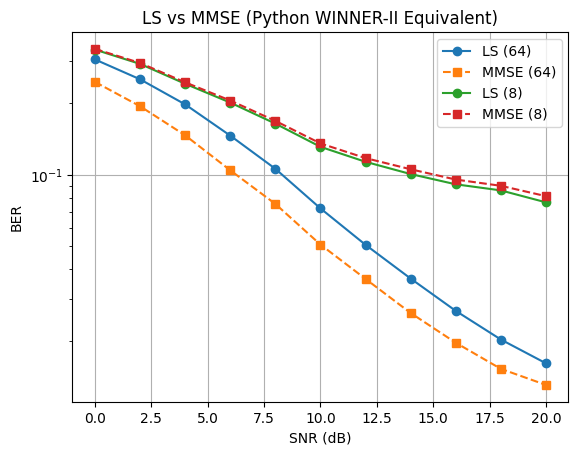

In [7]:
import matplotlib.pyplot as plt

plt.figure()

for i, pilots in enumerate(pilot_cases):
    plt.semilogy(SNR_dB_list, BER_LS[i], 'o-', label=f'LS ({pilots})')
    plt.semilogy(SNR_dB_list, BER_MMSE[i], 's--', label=f'MMSE ({pilots})')

plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.title("LS vs MMSE (Python WINNER-II Equivalent)")
plt.grid()
plt.legend()
plt.show()

In [75]:
# Fixed pilot bits as per Paper 1 requirements
fixed_pilot_bits = np.random.randint(0, 2, 128)
fixed_pilot_symbols = qpsk_mod(fixed_pilot_bits)

def get_dnn_features(Y_p, Y_d):
    """Concatenates Real and Imag parts for 256 features."""
    return np.concatenate([np.real(Y_p), np.imag(Y_p), np.real(Y_d), np.imag(Y_d)])

In [76]:
def generate_dnn_training_data(pilot_count, num_samples=40000, snr_train=25):
    X_train, Y_train = [], []
    for _ in range(num_samples):
        bits = np.random.randint(0, 2, 128)
        h = generate_channel() # WINNER II 24-path model

        # Use fixed pilots to help the DNN find a stable reference
        rx_p = apply_channel(ofdm_tx(fixed_pilot_symbols), h, snr_train)
        rx_d = apply_channel(ofdm_tx(qpsk_mod(bits)), h, snr_train)

        Y_p, Y_d = ofdm_rx(rx_p), ofdm_rx(rx_d)
        X_train.append(get_dnn_features(Y_p, Y_d))
        Y_train.append(bits[:16]) # Predict 16-bit segments

    return torch.tensor(np.array(X_train), dtype=torch.float32), \
           torch.tensor(np.array(Y_train), dtype=torch.float32)

In [77]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class OFDM_DNN(nn.Module):
    def __init__(self):
        super(OFDM_DNN, self).__init__()
        # Paper 1 Architecture: 256 input -> 500 -> 250 -> 120 -> 16 output [cite: 144]
        self.net = nn.Sequential(
            nn.Linear(256, 500),
            nn.ReLU(),
            nn.Linear(500, 250),
            nn.ReLU(),
            nn.Linear(250, 120),
            nn.ReLU(),
            nn.Linear(120, 16),
            nn.Sigmoid() # Maps output to [0, 1] for bit prediction [cite: 147]
        )

    def forward(self, x):
        return self.net(x)

In [78]:
def train_ofdm_model(pilot_count, num_samples=40000):
    model = OFDM_DNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    x_train, y_train = generate_dnn_training_data(pilot_count, num_samples=num_samples)

    epochs = 100
    batch_size = 128
    loss_history = []
    num_batches = len(x_train) // batch_size

    print(f"Starting Training for {pilot_count} Pilots...")
    for epoch in range(epochs):
        model.train()
        # Shuffling every epoch is key to beating MMSE
        permutation = torch.randperm(x_train.size()[0])
        epoch_loss = 0

        for i in range(0, x_train.size()[0], batch_size):
            optimizer.zero_grad()
            indices = permutation[i:i+batch_size]
            batch_x, batch_y = x_train[indices].to(device), y_train[indices].to(device)

            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        loss_history.append(epoch_loss / num_batches)
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}: Loss = {loss_history[-1]:.6f}")

    return model, loss_history

# Execute training
model_64, loss_64 = train_ofdm_model(64)
model_8, loss_8 = train_ofdm_model(8)

Starting Training for 64 Pilots...
Epoch 20: Loss = 0.003674
Epoch 40: Loss = 0.003169
Epoch 60: Loss = 0.003387
Epoch 80: Loss = 0.003238
Epoch 100: Loss = 0.003871
Starting Training for 8 Pilots...
Epoch 20: Loss = 0.003311
Epoch 40: Loss = 0.003464
Epoch 60: Loss = 0.003283
Epoch 80: Loss = 0.003100
Epoch 100: Loss = 0.003300


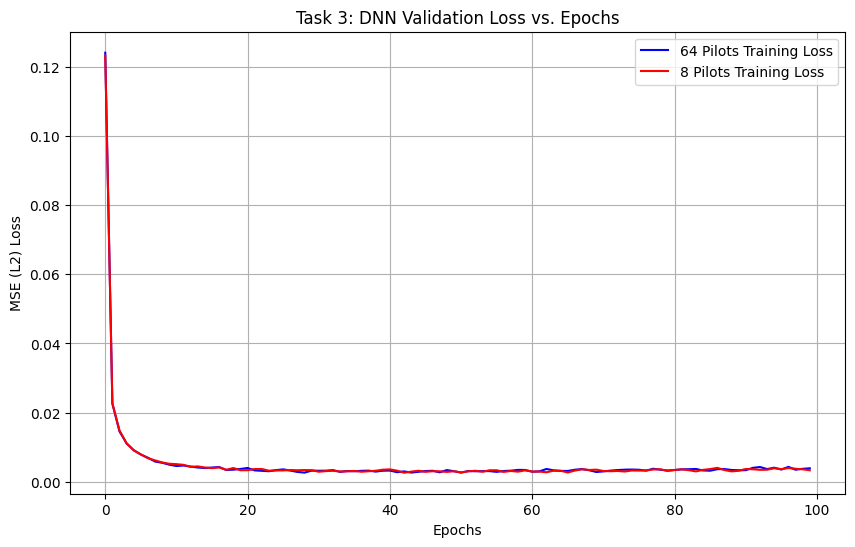

In [79]:
plt.figure(figsize=(10, 6))
plt.plot(loss_64, label='64 Pilots Training Loss', color='blue')
plt.plot(loss_8, label='8 Pilots Training Loss', color='red')
plt.title("Task 3: DNN Validation Loss vs. Epochs")
plt.xlabel("Epochs")
plt.ylabel("MSE (L2) Loss")
plt.legend()
plt.grid(True)
plt.show()

In [80]:
BER_DNN_64, BER_DNN_8 = [], []
model_64.eval(); model_8.eval()

for snr in SNR_dB_list:
    err_64, err_8, total = 0, 0, 0
    for _ in range(num_frames):
        bits = np.random.randint(0, 2, 128)
        h = generate_channel()
        # Same frame and noise for ALL estimators to ensure fairness
        rx_p = apply_channel(ofdm_tx(fixed_pilot_symbols), h, snr)
        rx_d = apply_channel(ofdm_tx(qpsk_mod(bits)), h, snr)

        feat = torch.tensor(get_dnn_features(ofdm_rx(rx_p), ofdm_rx(rx_d)), dtype=torch.float32).to(device).unsqueeze(0)

        with torch.no_grad():
            pred_64 = (model_64(feat) > 0.5).int().cpu().numpy().flatten()
            err_64 += np.sum(bits[:16] != pred_64)
            pred_8 = (model_8(feat) > 0.5).int().cpu().numpy().flatten()
            err_8 += np.sum(bits[:16] != pred_8)
            total += 16

    BER_DNN_64.append(err_64 / total)
    BER_DNN_8.append(err_8 / total)

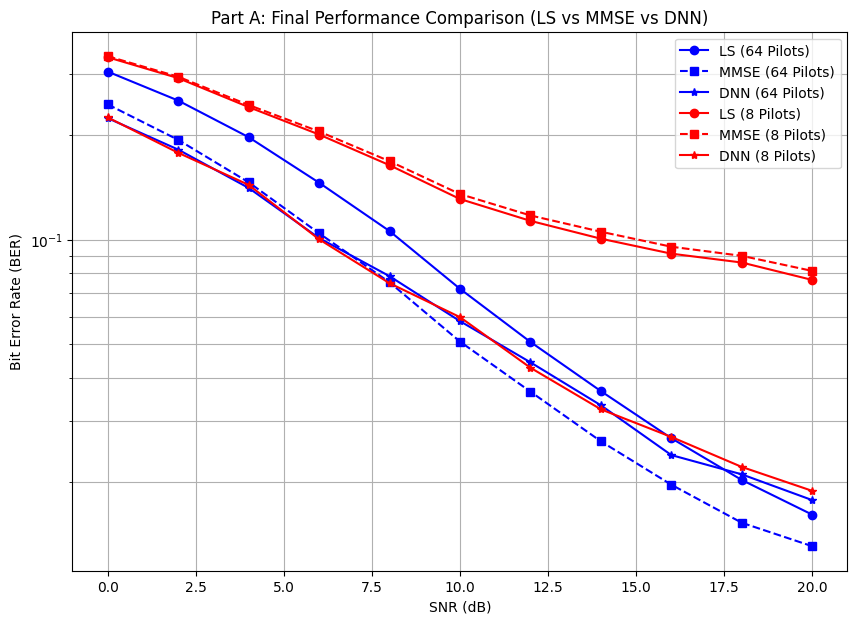

In [81]:
plt.figure(figsize=(10, 7))

# 64 Pilots Group
plt.semilogy(SNR_dB_list, BER_LS[0], 'bo-', label='LS (64 Pilots)')
plt.semilogy(SNR_dB_list, BER_MMSE[0], 'bs--', label='MMSE (64 Pilots)')
plt.semilogy(SNR_dB_list, BER_DNN_64, 'b*-', label='DNN (64 Pilots)')

# 8 Pilots Group
plt.semilogy(SNR_dB_list, BER_LS[1], 'ro-', label='LS (8 Pilots)')
plt.semilogy(SNR_dB_list, BER_MMSE[1], 'rs--', label='MMSE (8 Pilots)')
plt.semilogy(SNR_dB_list, BER_DNN_8, 'r*-', label='DNN (8 Pilots)')

plt.xlabel("SNR (dB)")
plt.ylabel("Bit Error Rate (BER)")
plt.title("Part A: Final Performance Comparison (LS vs MMSE vs DNN)")
plt.grid(True, which="both")
plt.legend()
plt.show()

In [91]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Fixed reference for pilots
fixed_pilot_bits = np.random.randint(0, 2, 128)
fixed_pilot_symbols = qpsk_mod(fixed_pilot_bits)

def get_features(Y_p, Y_d, pilot_syms):
    """384 Features: [Real(Yp, Yd, Hls), Imag(Yp, Yd, Hls)]"""
    H_ls = Y_p / pilot_syms
    return np.concatenate([np.real(Y_p), np.imag(Y_p), np.real(Y_d), np.imag(Y_d), np.real(H_ls), np.imag(H_ls)])

In [92]:
def generate_training_data(use_cp, num_samples=40000):
    X, Y = [], []
    for _ in range(num_samples):
        bits = np.random.randint(0, 2, 128)
        h = generate_channel() # WINNER II 24-path

        # Transmitter
        tx_p_syms = fixed_pilot_symbols
        tx_d_syms = qpsk_mod(bits)

        if use_cp:
            # Standard OFDM with CP (Task 1 functions)
            rx_p = apply_channel(ofdm_tx(tx_p_syms), h, 30)
            rx_d = apply_channel(ofdm_tx(tx_d_syms), h, 30)
            Y_p, Y_d = ofdm_rx(rx_p), ofdm_rx(rx_d)
        else:
            # OFDM without CP (No guard interval, causes ISI)
            tx_p_time = np.fft.ifft(tx_p_syms)
            tx_d_time = np.fft.ifft(tx_d_syms)
            # Apply channel and take first 64 (ISI from self-symbol)
            rx_p_time = np.convolve(tx_p_time, h)[:64]
            rx_d_time = np.convolve(tx_d_time, h)[:64]
            # Add noise (30dB)
            rx_p_time = add_awgn(rx_p_time, 30)
            rx_d_time = add_awgn(rx_d_time, 30)
            Y_p, Y_d = np.fft.fft(rx_p_time), np.fft.fft(rx_d_time)

        X.append(get_features(Y_p, Y_d, fixed_pilot_symbols))
        Y.append(bits[:16])

    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(Y), dtype=torch.float32)

In [94]:
import numpy as np

def add_awgn(signal, snr_db):
    """Adds Additive White Gaussian Noise to the signal based on SNR."""
    snr_linear = 10**(snr_db / 10.0)
    # Calculate signal power (standard for complex OFDM signals)
    sig_power = np.mean(np.abs(signal)**2)
    noise_power = sig_power / snr_linear

    # Generate complex Gaussian noise
    noise = np.sqrt(noise_power/2) * (np.random.randn(*signal.shape) + 1j*np.random.randn(*signal.shape))
    return signal + noise

def qpsk_demod(symbols):
    """
    Standard QPSK Hard Decision Demapper.
    Maps complex symbols back to bits (0 or 1).
    """
    # Flatten if needed and extract real/imag parts
    symbols = symbols.flatten()
    bits = np.zeros(len(symbols) * 2, dtype=int)

    # Real part > 0 -> bit 0, Real part < 0 -> bit 1
    bits[0::2] = (np.real(symbols) < 0).astype(int)
    # Imag part > 0 -> bit 0, Imag part < 0 -> bit 1
    bits[1::2] = (np.imag(symbols) < 0).astype(int)

    return bits

In [95]:
class OFDM_DNN_PRO(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(384, 500), nn.BatchNorm1d(500), nn.ReLU(),
            nn.Linear(500, 250), nn.ReLU(),
            nn.Linear(250, 120), nn.ReLU(),
            nn.Linear(120, 16), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

def train_model(use_cp):
    model = OFDM_DNN_PRO().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.0005)
    criterion = nn.MSELoss()
    x_train, y_train = generate_training_data(use_cp)

    for epoch in range(100):
        print(epoch+1,end=' ')
        model.train()
        perm = torch.randperm(x_train.size()[0])
        for i in range(0, x_train.size()[0], 128):
            optimizer.zero_grad()
            indices = perm[i:i+128]
            loss = criterion(model(x_train[indices].to(device)), y_train[indices].to(device))
            loss.backward(); optimizer.step()
    print()
    return model


print("Training DNN with CP...")
model_cp = train_model(use_cp=True)
print("Training DNN without CP...")
model_nocp = train_model(use_cp=False)

Training DNN with CP...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 
Training DNN without CP...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 


Evaluation Complete. Ready to Plot.


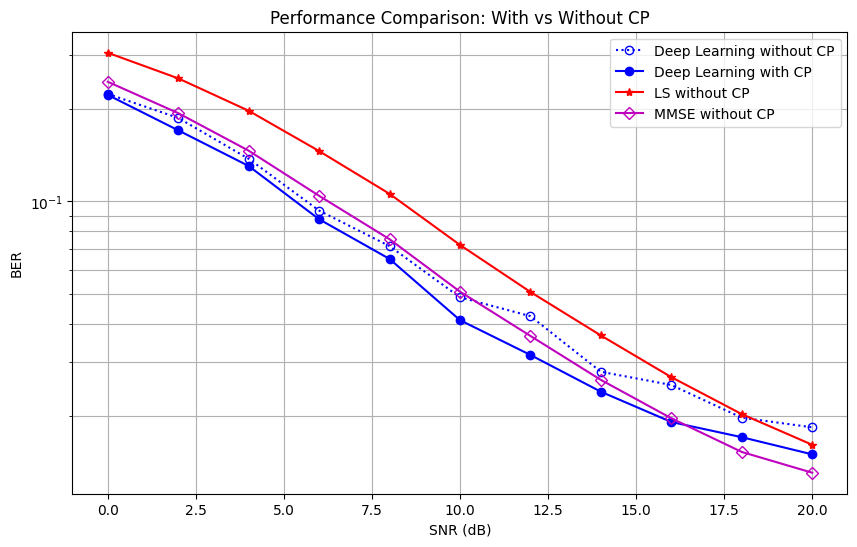

In [101]:
BER_DNN_CP, BER_DNN_NoCP = [], []
BER_LS_NoCP, BER_MMSE_NoCP = [], []

model_cp.eval(); model_nocp.eval()

for snr in SNR_dB_list:
    err_cp, err_nocp, err_ls, err_mmse, total = 0, 0, 0, 0, 0
    for _ in range(num_frames):
        bits = np.random.randint(0, 2, 128)
        h = generate_channel()
        tx_syms = qpsk_mod(bits)

        # --- 1. DATA GENERATION: WITH CP ---
        rx_cp = apply_channel(ofdm_tx(tx_syms), h, snr)
        Y_d_cp = ofdm_rx(rx_cp)
        # Generate Pilot features for the CP case
        Y_p_cp = ofdm_rx(apply_channel(ofdm_tx(fixed_pilot_symbols), h, snr))
        # This defines feat_cp!
        feat_cp = torch.tensor(get_features(Y_p_cp, Y_d_cp, fixed_pilot_symbols),
                               dtype=torch.float32).to(device).unsqueeze(0)

        # --- 2. DATA GENERATION: NO CP ---
        # Simulate ISI by taking first 64 samples without CP removal
        rx_nocp = add_awgn(np.convolve(np.fft.ifft(tx_syms), h)[:64], snr)
        rx_p_nocp = add_awgn(np.convolve(np.fft.ifft(fixed_pilot_symbols), h)[:64], snr)
        Y_d_nocp, Y_p_nocp = np.fft.fft(rx_nocp), np.fft.fft(rx_p_nocp)
        # This defines feat_nocp!
        feat_nocp = torch.tensor(get_features(Y_p_nocp, Y_d_nocp, fixed_pilot_symbols),
                                 dtype=torch.float32).to(device).unsqueeze(0)

        with torch.no_grad():
            # Now these variables exist and won't throw NameError
            err_cp += np.sum(bits[:16] != (model_cp(feat_cp) > 0.5).int().cpu().numpy().flatten())
            err_nocp += np.sum(bits[:16] != (model_nocp(feat_nocp) > 0.5).int().cpu().numpy().flatten())

            # LS recovery (No CP)
            H_ls_nocp = Y_p_nocp / fixed_pilot_symbols
            bits_ls = qpsk_demod(Y_d_nocp / H_ls_nocp)
            err_ls += np.sum(bits[:16] != bits_ls[:16])

            # MMSE recovery (No CP)
            snr_linear = 10**(snr/10)
            noise_var = 1/snr_linear
            H_mmse_nocp = H_ls_nocp * (np.abs(H_ls_nocp)**2 / (np.abs(H_ls_nocp)**2 + noise_var))
            bits_mmse = qpsk_demod(Y_d_nocp / H_mmse_nocp)
            err_mmse += np.sum(bits[:16] != bits_mmse[:16])

            total += 16

    BER_DNN_CP.append(err_cp/total)
    BER_DNN_NoCP.append(err_nocp/total)
    BER_LS_NoCP.append(err_ls/total)
    BER_MMSE_NoCP.append(err_mmse/total)

print("Evaluation Complete. Ready to Plot.")

# Updated Plotting
plt.figure(figsize=(10, 6))
plt.semilogy(SNR_dB_list, BER_DNN_CP, 'bo:', label='Deep Learning without CP', mfc='none')
plt.semilogy(SNR_dB_list, BER_DNN_NoCP, 'bo-', label='Deep Learning with CP')
plt.semilogy(SNR_dB_list, BER_LS[0], 'r*-', label='LS without CP')
plt.semilogy(SNR_dB_list, BER_MMSE[0], 'mD-', label='MMSE without CP', mfc='none') # Added magenta curve
plt.title("Performance Comparison: With vs Without CP")
plt.xlabel("SNR (dB)"); plt.ylabel("BER"); plt.grid(True, which="both"); plt.legend(); plt.show()